<a href="https://colab.research.google.com/github/weloo11/mnist-image-classifier/blob/main/linearSVM(HOG)v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from skimage.feature import hog

In [2]:
# =========================================
# 1) Choose target digit
# =========================================
TARGET_DIGIT = 5

In [3]:
# =========================================
# 2) Load MNIST
# =========================================
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# =========================================
# 3) Combine full dataset
# =========================================
X = np.concatenate([X_train_full, X_test_full], axis=0)
y = np.concatenate([y_train_full, y_test_full], axis=0)

print("Image data shape:", X.shape)
print("Label shape:", y.shape)
print("Unique labels:", np.unique(y))

Image data shape: (70000, 28, 28)
Label shape: (70000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


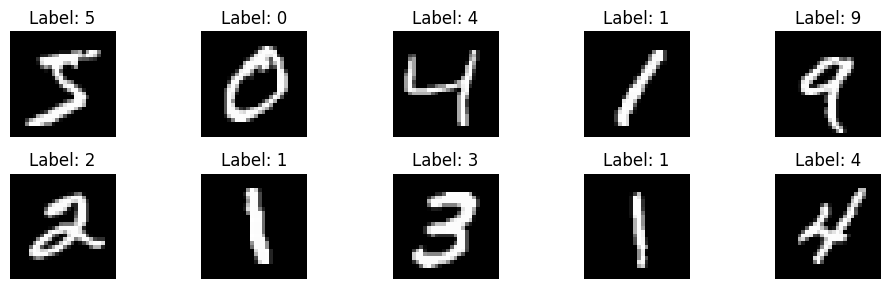

In [5]:
# =========================================
# 4) Show sample images
# =========================================
plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i], cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
# =========================================
# 5) Convert labels to binary
#    1 = target digit
#    0 = not target digit
# =========================================
y_binary = (y == TARGET_DIGIT).astype(int)

num_positive = np.sum(y_binary == 1)
num_negative = np.sum(y_binary == 0)

print("Target digit:", TARGET_DIGIT)
print("Positive samples:", num_positive)
print("Negative samples:", num_negative)
print("Positive ratio:", num_positive / len(y_binary))
print("Negative ratio:", num_negative / len(y_binary))

Target digit: 5
Positive samples: 6313
Negative samples: 63687
Positive ratio: 0.09018571428571429
Negative ratio: 0.9098142857142857


In [7]:
# =========================================
# 6) Normalize images to [0,1]
# =========================================
X = X.astype("float32") / 255.0

print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [8]:
# =========================================
# 7) Stratified split: train / val / test
# =========================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary,
    test_size=0.30,
    random_state=42,
    stratify=y_binary
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

def print_class_distribution(name, labels):
    positives = np.sum(labels == 1)
    negatives = np.sum(labels == 0)
    total = len(labels)
    print(f"{name}:")
    print(f"  Positives = {positives} ({positives / total:.4f})")
    print(f"  Negatives = {negatives} ({negatives / total:.4f})")

print_class_distribution("Training set", y_train)
print_class_distribution("Validation set", y_val)
print_class_distribution("Test set", y_test)

Train shape: (49000, 28, 28) (49000,)
Validation shape: (10500, 28, 28) (10500,)
Test shape: (10500, 28, 28) (10500,)
Training set:
  Positives = 4419 (0.0902)
  Negatives = 44581 (0.9098)
Validation set:
  Positives = 947 (0.0902)
  Negatives = 9553 (0.9098)
Test set:
  Positives = 947 (0.0902)
  Negatives = 9553 (0.9098)


In [9]:
# =========================================
# 8) HOG feature extraction
# =========================================
def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        hog_features.append(features)
    return np.array(hog_features)

sample_hog = hog(
    X_train[0],
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys'
)
print("HOG feature length for one image:", len(sample_hog))

X_train_hog = extract_hog_features(X_train)
X_val_hog   = extract_hog_features(X_val)
X_test_hog  = extract_hog_features(X_test)

print("HOG training shape:", X_train_hog.shape)
print("HOG validation shape:", X_val_hog.shape)
print("HOG test shape:", X_test_hog.shape)

HOG feature length for one image: 1296
HOG training shape: (49000, 1296)
HOG validation shape: (10500, 1296)
HOG test shape: (10500, 1296)


In [10]:
# =========================================
# 9) Standardize HOG features
# =========================================
hog_scaler = StandardScaler()

X_train_hog_scaled = hog_scaler.fit_transform(X_train_hog)
X_val_hog_scaled   = hog_scaler.transform(X_val_hog)
X_test_hog_scaled  = hog_scaler.transform(X_test_hog)

print("Scaled HOG training shape:", X_train_hog_scaled.shape)
print("Scaled HOG validation shape:", X_val_hog_scaled.shape)
print("Scaled HOG test shape:", X_test_hog_scaled.shape)

Scaled HOG training shape: (49000, 1296)
Scaled HOG validation shape: (10500, 1296)
Scaled HOG test shape: (10500, 1296)


In [11]:
# =========================================
# 10) Save preprocessed arrays as .npy
# =========================================
np.save("X_train_hog.npy", X_train_hog_scaled)
np.save("X_val_hog.npy", X_val_hog_scaled)
np.save("X_test_hog.npy", X_test_hog_scaled)

np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("y_test.npy", y_test)

print("Preprocessed HOG features and labels saved as .npy files.")

Preprocessed HOG features and labels saved as .npy files.


In [12]:
# =========================================
# 11) Train Linear SVM
# =========================================
svm_model = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=5000
)

svm_model.fit(X_train_hog_scaled, y_train)

LinearSVC(class_weight='balanced', max_iter=5000, random_state=42)

In [13]:
# =========================================
# 12) Validation evaluation
# =========================================
y_val_pred = svm_model.predict(X_val_hog_scaled)

print("\n===== VALIDATION RESULTS =====")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1-score :", f1_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))



===== VALIDATION RESULTS =====
Accuracy : 0.9917142857142857
Precision: 0.946985446985447
Recall   : 0.9619852164730729
F1-score : 0.9544264012572027
Confusion Matrix:
 [[9502   51]
 [  36  911]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      9553
           1       0.95      0.96      0.95       947

    accuracy                           0.99     10500
   macro avg       0.97      0.98      0.97     10500
weighted avg       0.99      0.99      0.99     10500



In [14]:
# =========================================
# 13) Test evaluation
# =========================================
y_test_pred = svm_model.predict(X_test_hog_scaled)

print("\n===== TEST RESULTS =====")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1-score :", f1_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


===== TEST RESULTS =====
Accuracy : 0.9918095238095238
Precision: 0.9442724458204335
Recall   : 0.9662090813093981
F1-score : 0.9551148225469729
Confusion Matrix:
 [[9499   54]
 [  32  915]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      9553
           1       0.94      0.97      0.96       947

    accuracy                           0.99     10500
   macro avg       0.97      0.98      0.98     10500
weighted avg       0.99      0.99      0.99     10500

